# DBGSOM vs. sklearn Clustering — Comparison

This notebook benchmarks DBGSOM (`SomVQ`) against the most comparable sklearn clustering algorithms
on two datasets: **Iris** (small, low-dimensional) and **Digits** (larger, high-dimensional).

## Algorithm Overview

| Property            | DBGSOM                      | KMeans               | MiniBatchKMeans      | AgglomerativeClustering |
| ------------------- | --------------------------- | -------------------- | -------------------- | ----------------------- |
| Learning rule       | Batch SOM                   | Lloyd's algorithm    | Mini-batch Lloyd     | Ward / linkage          |
| Prototype count     | **Adaptive** (grows from 4) | Fixed (`n_clusters`) | Fixed (`n_clusters`) | Fixed (`n_clusters`)    |
| Topology preserved  | **Yes** (grid graph)        | No                   | No                   | No                      |
| Predict on new data | Yes                         | Yes                  | Yes                  | No                      |
| sklearn-compatible  | **Yes**                     | Yes                  | Yes                  | Yes                     |
| Complexity (fit)    | O(e·(n·m·d + m²·d) + m⁴)    | O(n·k·d·e)           | O(n·k·d·b)           | O(n²·d)                 |

> **Fair comparison:** DBGSOM is trained first to determine its final neuron count `m`.
> All other algorithms are then configured with `n_clusters = m` so every model uses the same prototype budget.


## Imports


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans, MiniBatchKMeans
from sklearn.datasets import load_digits, load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from dbgsom.SomVQ import SomVQ

## Datasets


In [2]:
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

digits = load_digits()
X_digits = StandardScaler().fit_transform(digits.data)
y_digits = digits.target

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)
X_digits_train, X_digits_test, y_digits_train, y_digits_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42, stratify=y_digits
)

print(
    f"Iris:   {X_iris.shape[0]} samples × {X_iris.shape[1]} features, {len(np.unique(y_iris))} classes"
    f"  (train={len(X_iris_train)}, test={len(X_iris_test)})"
)
print(
    f"Digits: {X_digits.shape[0]} samples × {X_digits.shape[1]} features, {len(np.unique(y_digits))} classes"
    f"  (train={len(X_digits_train)}, test={len(X_digits_test)})"
)

Iris:   150 samples × 4 features, 3 classes  (train=120, test=30)
Digits: 1797 samples × 64 features, 10 classes  (train=1437, test=360)


## Helper Functions


In [3]:
import seaborn as sns


def compute_qe(X, labels):
    """Mean Euclidean distance from each sample to its cluster centroid."""
    unique_labels = np.unique(labels)
    centroids = np.array([X[labels == k].mean(axis=0) for k in unique_labels])
    label_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
    centroid_idx = np.array([label_to_idx[lbl] for lbl in labels])
    return float(np.mean(np.linalg.norm(X - centroids[centroid_idx], axis=1)))


def build_row(X, y_true, labels, name, t, qe=None, te=None):
    return {
        "Algorithm": name,
        "Time (s)": round(t, 3),
        "Clusters": int(len(np.unique(labels))),
        "ARI": round(adjusted_rand_score(y_true, labels), 3),
        "Silhouette": round(silhouette_score(X, labels), 3),
        "Davies-Bouldin": round(davies_bouldin_score(X, labels), 3),
        "Calinski-Harabasz": round(calinski_harabasz_score(X, labels), 1),
        "QE": round(qe if qe is not None else compute_qe(X, labels), 4),
        "Topographic Error": round(te, 4) if te is not None else "—",
    }


def plot_metrics(rows, dataset_name):
    df = pd.DataFrame(rows).set_index("Algorithm")
    n = len(df)
    colors = sns.color_palette("muted", n_colors=n)
    metric_specs = [
        ("ARI", "ARI (↑ better)"),
        ("Silhouette", "Silhouette (↑ better)"),
        ("Davies-Bouldin", "Davies-Bouldin (↓ better)"),
        ("Time (s)", "Training time / s (↓ better)"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f"Metric comparison — {dataset_name}", fontsize=13)
    for ax, (col, label) in zip(axes, metric_specs):
        vals = df[col].astype(float)
        bars = ax.bar(vals.index, vals.values, color=colors)
        ax.set_title(label, fontsize=10)
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(vals.index, rotation=40, ha="right", fontsize=9)
        for bar, val in zip(bars, vals.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()


def plot_pca_clusters(X, labels_dict, dataset_name):
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)
    n_algs = len(labels_dict)
    fig, axes = plt.subplots(1, n_algs, figsize=(5 * n_algs, 4))
    fig.suptitle(f"Cluster assignments in PCA space — {dataset_name}", fontsize=13)
    for ax, (name, labels) in zip(axes, labels_dict.items()):
        ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab20", s=10, alpha=0.7)
        n = len(np.unique(labels))
        ax.set_title(f"{name}\n({n} clusters)", fontsize=10)
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

---

## Dataset 1: Iris

150 samples, 4 features, 3 ground-truth classes.
A small, well-separated dataset — good for a sanity check.


In [4]:
# --- DBGSOM (determines n_clusters for all other algorithms) ---
t0 = time.perf_counter()
som_iris = SomVQ(
    n_iter=1000,
    spreading_factor=0.5,
    sigma_end=0.5,
    max_neurons=50,
    random_state=42,
)
som_iris.fit(X_iris_train)
t_som = time.perf_counter() - t0
n_clusters_iris = len(som_iris.neurons_)
labels_som = som_iris.predict(X_iris_test)
print(f"DBGSOM:  {n_clusters_iris} neurons in {t_som:.3f}s")

# --- KMeans ---
t0 = time.perf_counter()
km_iris = KMeans(n_clusters=n_clusters_iris, random_state=42, n_init=10)
km_iris.fit(X_iris_train)
t_km = time.perf_counter() - t0
labels_km = km_iris.predict(X_iris_test)
print(f"KMeans:  {n_clusters_iris} clusters in {t_km:.3f}s")

# --- MiniBatchKMeans ---
t0 = time.perf_counter()
mbkm_iris = MiniBatchKMeans(n_clusters=n_clusters_iris, random_state=42, n_init=10)
mbkm_iris.fit(X_iris_train)
t_mbkm = time.perf_counter() - t0
labels_mbkm = mbkm_iris.predict(X_iris_test)
print(f"MiniBatch: {n_clusters_iris} clusters in {t_mbkm:.3f}s")

# --- AgglomerativeClustering (no predict — fit_predict on test) ---
t0 = time.perf_counter()
agg_iris = AgglomerativeClustering(n_clusters=n_clusters_iris)
labels_agg = agg_iris.fit_predict(X_iris_test)
t_agg = time.perf_counter() - t0
print(f"Agglom.: {n_clusters_iris} clusters in {t_agg:.3f}s")

C:\Users\smartens\AppData\Local\Temp\ipykernel_33604\2937899037.py:10: UserWarning: No growth occurred during training. The map stayed at 4 neurons. Consider lowering convergence_threshold or increasing spreading_factor.
  som_iris.fit(X_iris_train)


DBGSOM:  4 neurons in 1.054s
KMeans:  4 clusters in 1.904s
MiniBatch: 4 clusters in 0.035s
Agglom.: 4 clusters in 0.004s


### Metrics — Iris

- **ARI** (Adjusted Rand Index): measures agreement with the ground-truth labels, 1 = perfect.
- **Silhouette**: measures within-cluster cohesion vs. between-cluster separation, 1 = perfect.
- **Davies-Bouldin**: ratio of within- to between-cluster scatter, lower is better.
- **QE** (Quantization Error): mean Euclidean distance from each sample to its assigned centroid.
- **Topographic Error**: fraction of samples whose 1st and 2nd BMU are not adjacent on the grid (DBGSOM only).


In [5]:
rows_iris = [
    build_row(
        X_iris_test,
        y_iris_test,
        labels_som,
        "DBGSOM",
        t_som,
        qe=som_iris.calculate_quantization_error(X_iris_test),
        te=som_iris.topographic_error_,
    ),
    build_row(X_iris_test, y_iris_test, labels_km, "KMeans", t_km),
    build_row(X_iris_test, y_iris_test, labels_mbkm, "MiniBatchKMeans", t_mbkm),
    build_row(X_iris_test, y_iris_test, labels_agg, "AgglomerativeClustering", t_agg),
]

df_iris = pd.DataFrame(rows_iris).set_index("Algorithm")
df_iris

,Time (s),Clusters,ARI,Silhouette,Davies-Bouldin,Calinski-Harabasz,QE,Topographic Error
Algorithm,,,,,,,,
DBGSOM,1.054,4,0.373,0.278,0.943,40.6,0.7845,0.0
KMeans,1.904,4,0.390,0.258,0.998,39.3,0.7322,—
MiniBatchKMeans,0.035,4,0.352,0.272,0.991,40.7,0.7287,—
AgglomerativeClustering,0.004,4,0.431,0.537,0.547,56.1,0.6285,—


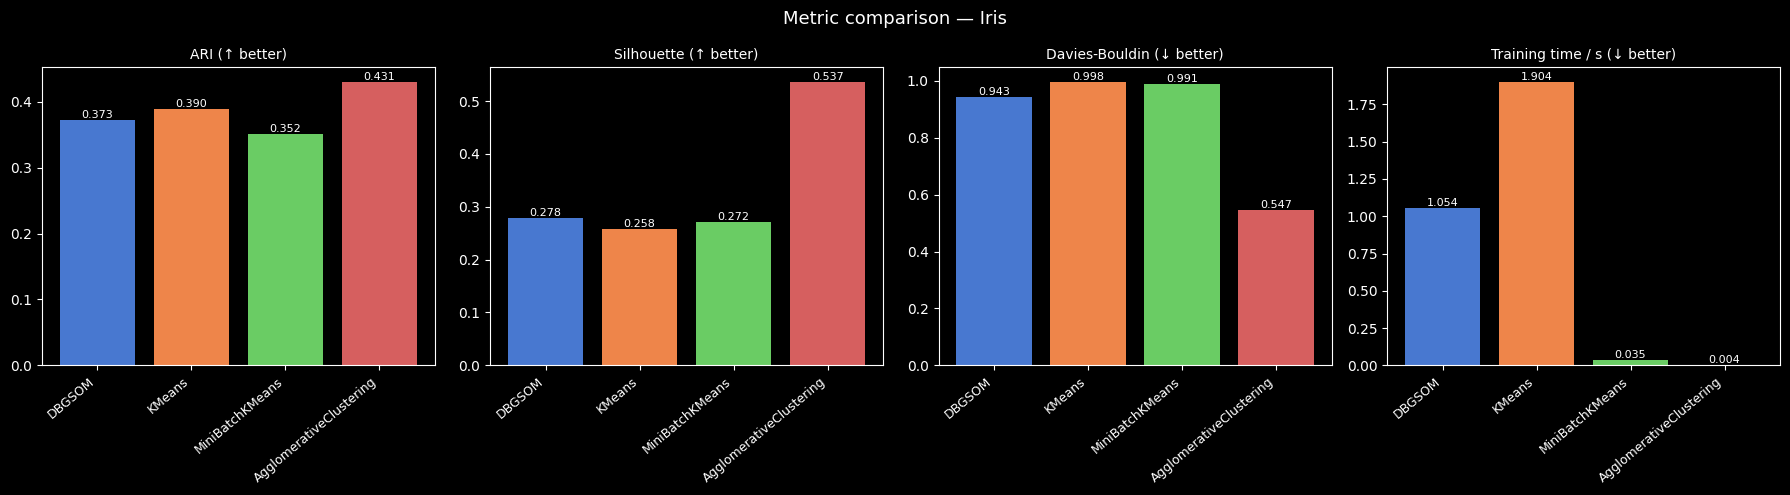

In [6]:
plot_metrics(rows_iris, "Iris")

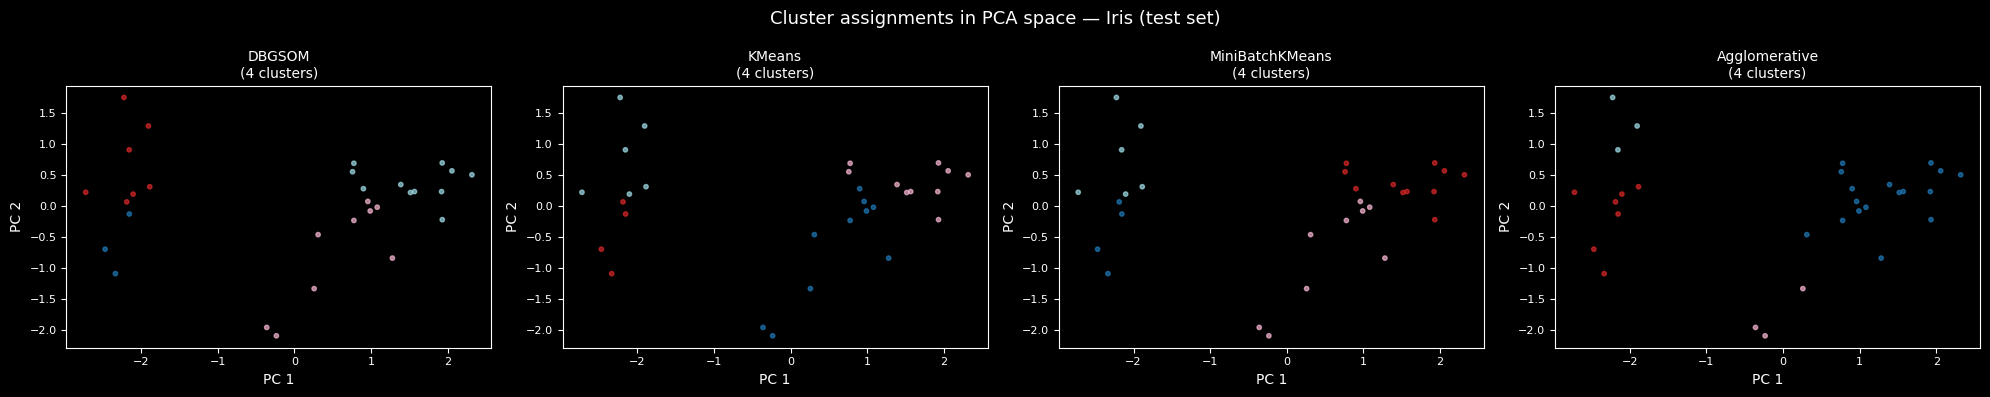

In [7]:
plot_pca_clusters(
    X_iris_test,
    {
        "DBGSOM": labels_som,
        "KMeans": labels_km,
        "MiniBatchKMeans": labels_mbkm,
        "Agglomerative": labels_agg,
    },
    "Iris (test set)",
)

---

## Dataset 2: Digits

1 797 samples, 64 features (8×8 pixel images of handwritten digits 0–9), 10 ground-truth classes.
A realistic, higher-dimensional dataset — the same one used in the MiniSom comparison notebook.


In [8]:
# --- DBGSOM (determines n_clusters for all other algorithms) ---
t0 = time.perf_counter()
som_digits = SomVQ(
    n_iter=500,
    spreading_factor=0.9,
    max_neurons=100,
    random_state=42,
    verbose=True,
)
som_digits.fit(X_digits_train)
t_som_d = time.perf_counter() - t0
n_clusters_digits = len(som_digits.neurons_)
labels_som_d = som_digits.predict(X_digits_test)
print(f"DBGSOM:  {n_clusters_digits} neurons in {t_som_d:.3f}s")

# --- KMeans ---
t0 = time.perf_counter()
km_digits = KMeans(n_clusters=n_clusters_digits, random_state=42, n_init=10)
km_digits.fit(X_digits_train)
t_km_d = time.perf_counter() - t0
labels_km_d = km_digits.predict(X_digits_test)
print(f"KMeans:  {n_clusters_digits} clusters in {t_km_d:.3f}s")

# --- MiniBatchKMeans ---
t0 = time.perf_counter()
mbkm_digits = MiniBatchKMeans(n_clusters=n_clusters_digits, random_state=42, n_init=10)
mbkm_digits.fit(X_digits_train)
t_mbkm_d = time.perf_counter() - t0
labels_mbkm_d = mbkm_digits.predict(X_digits_test)
print(f"MiniBatch: {n_clusters_digits} clusters in {t_mbkm_d:.3f}s")

# --- AgglomerativeClustering (no predict — fit_predict on test) ---
t0 = time.perf_counter()
agg_digits = AgglomerativeClustering(n_clusters=n_clusters_digits)
labels_agg_d = agg_digits.fit_predict(X_digits_test)
t_agg_d = time.perf_counter() - t0
print(f"Agglom.: {n_clusters_digits} clusters in {t_agg_d:.3f}s")

 22%|██▏       | 112/500 [00:00<00:00, 887.03 epochs/s]


DBGSOM:  49 neurons in 0.144s
KMeans:  49 clusters in 0.125s
MiniBatch: 49 clusters in 0.098s
Agglom.: 49 clusters in 0.003s


### Metrics — Digits


In [9]:
rows_digits = [
    build_row(
        X_digits_test,
        y_digits_test,
        labels_som_d,
        "DBGSOM",
        t_som_d,
        qe=som_digits.calculate_quantization_error(X_digits_test),
        te=som_digits.topographic_error_,
    ),
    build_row(X_digits_test, y_digits_test, labels_km_d, "KMeans", t_km_d),
    build_row(X_digits_test, y_digits_test, labels_mbkm_d, "MiniBatchKMeans", t_mbkm_d),
    build_row(
        X_digits_test, y_digits_test, labels_agg_d, "AgglomerativeClustering", t_agg_d
    ),
]

df_digits = pd.DataFrame(rows_digits).set_index("Algorithm")
df_digits

,Time (s),Clusters,ARI,Silhouette,Davies-Bouldin,Calinski-Harabasz,QE,Topographic Error
Algorithm,,,,,,,,
DBGSOM,0.144,47,0.343,0.022,2.012,7.8,5.0873,0.2025
KMeans,0.125,44,0.372,0.102,1.655,17.8,4.1924,—
MiniBatchKMeans,0.098,47,0.346,0.085,1.734,14.1,4.2921,—
AgglomerativeClustering,0.003,49,0.360,0.146,1.370,19.4,3.8850,—


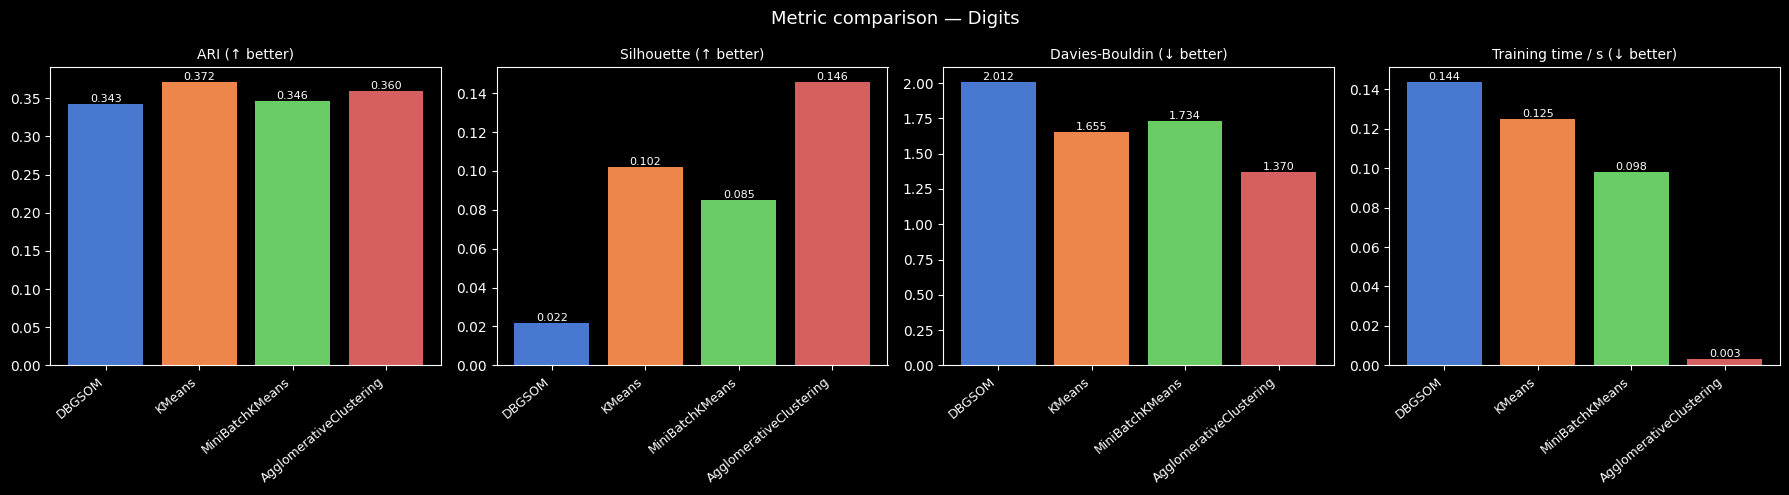

In [10]:
plot_metrics(rows_digits, "Digits")

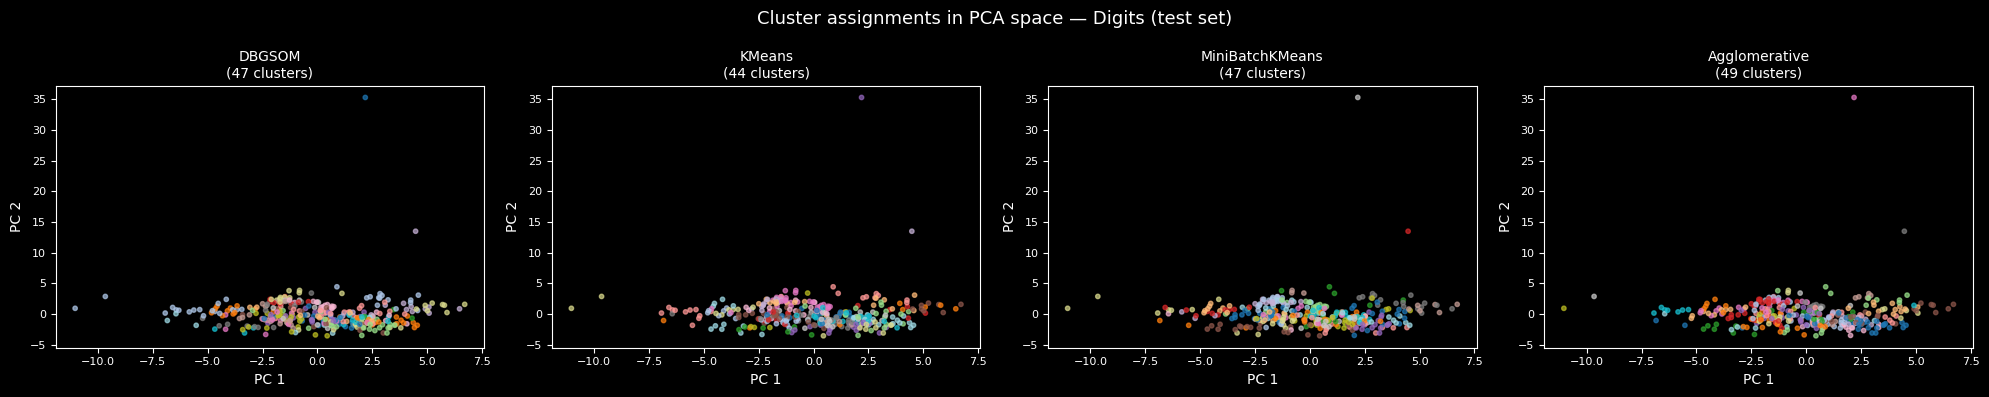

In [11]:
plot_pca_clusters(
    X_digits_test,
    {
        "DBGSOM": labels_som_d,
        "KMeans": labels_km_d,
        "MiniBatchKMeans": labels_mbkm_d,
        "Agglomerative": labels_agg_d,
    },
    "Digits (test set)",
)

### DBGSOM Map — Digits

DBGSOM also exposes the learned grid topology. The plot below shows each neuron in PCA space;
edges connect grid neighbours. Point size encodes how many training samples each neuron represents.


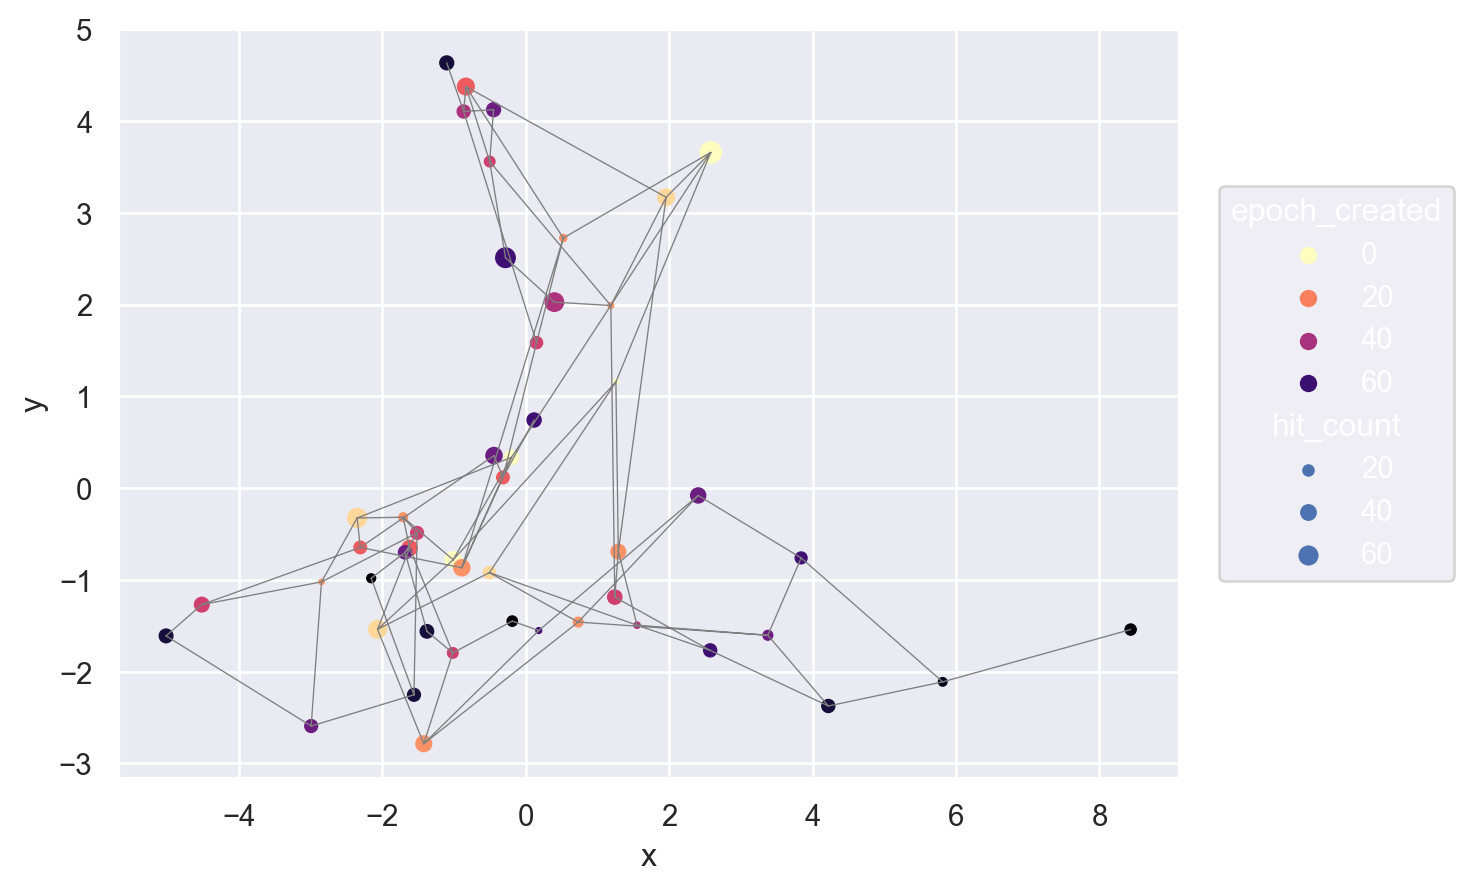

In [12]:
som_digits.plot(
    layout="pca", pointsize="hit_count", palette="magma_r", color="epoch_created"
)

---

## Summary

| Aspect                  | DBGSOM                                                    | KMeans                           | MiniBatchKMeans                | AgglomerativeClustering                   |
| ----------------------- | --------------------------------------------------------- | -------------------------------- | ------------------------------ | ----------------------------------------- |
| **Best for**            | Unknown map size; topology matters                        | Fast, general-purpose clustering | Large datasets, speed critical | Hierarchical structure; no predict needed |
| **Prototype count**     | Determined automatically                                  | Must be set in advance           | Must be set in advance         | Must be set in advance                    |
| **Topology**            | Grid graph preserved                                      | None                             | None                           | Dendrogram (not a grid)                   |
| **Predict on new data** | Yes                                                       | Yes                              | Yes                            | **No**                                    |
| **sklearn pipeline**    | Yes                                                       | Yes                              | Yes                            | Yes (fit only)                            |
| **Main cost**           | Floyd-Warshall on growth steps                            | Iterative centroid updates       | Mini-batch centroid updates    | Pairwise distance matrix O(n²)            |
| **Unique to DBGSOM**    | Topographic error, `plot()`, `transform()` (sparse codes) | —                                | —                              | —                                         |


In [13]:
som_digits

,spreading_factor,0.9
,verbose,True
,random_state,42
,n_iter,500
,sigma_start,None
,sigma_end,None
,sigma_fine,None
,vertical_growth,False
,decay_function,'exponential'
,neighborhood_function,'gaussian'
,coarse_training_frac,0.5
